# Описательные статистики в Python

**Дисциплина:** Введение в анализ больших данных

В этом занятии - базовые описательные статистики и простые графики для числовых и категориальных данных:
- среднее, стандартная ошибка, медиана, квантили;
- асимметрия и эксцесс;
- группировка (`groupby`);
- гистограмма с плотностью, boxplot, barplot.

Инструменты: **pandas**, **NumPy**, **SciPy**, **Matplotlib**, **Seaborn**.

Примеры построены на датасете **tips** (чаевые в ресторане). Они **не совпадают** с лабораторным заданием: цель — освоить методы, а само задание выполнить самостоятельно на своих данных.


## 0. Импорт и загрузка данных


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

df = pd.read_csv("NMES1988.csv", usecols=['visits', 'health', 'chronic', 'adl', 'region',
        'age', 'gender', 'married', 'school', 'income',
        'employed', 'insurance'])

print("Размерность:", df.shape)
df.head()



Размерность: (4406, 12)


,visits,health,chronic,adl,region,age,gender,married,school,income,employed,insurance
0,5,average,2,normal,other,6.9,male,yes,6,2.8810,yes,yes
1,1,average,2,normal,other,7.4,female,yes,10,2.7478,no,yes
2,13,poor,4,limited,other,6.6,female,no,10,0.6532,no,no
3,16,poor,2,limited,other,7.6,male,yes,3,0.6588,no,yes
4,3,average,2,limited,other,7.9,female,yes,6,0.6588,no,yes


In [ ]:
tips.describe(include="all")


---
## 1. Гистограмма числовой переменной + кривая плотности

Для непрерывного показателя удобно совместить:
- гистограмму (`density=True` — нормировка на плотность);
- ядерную оценку плотности (KDE) или теоретическую кривую.

Ниже — распределение **суммы счёта** (`total_bill`).


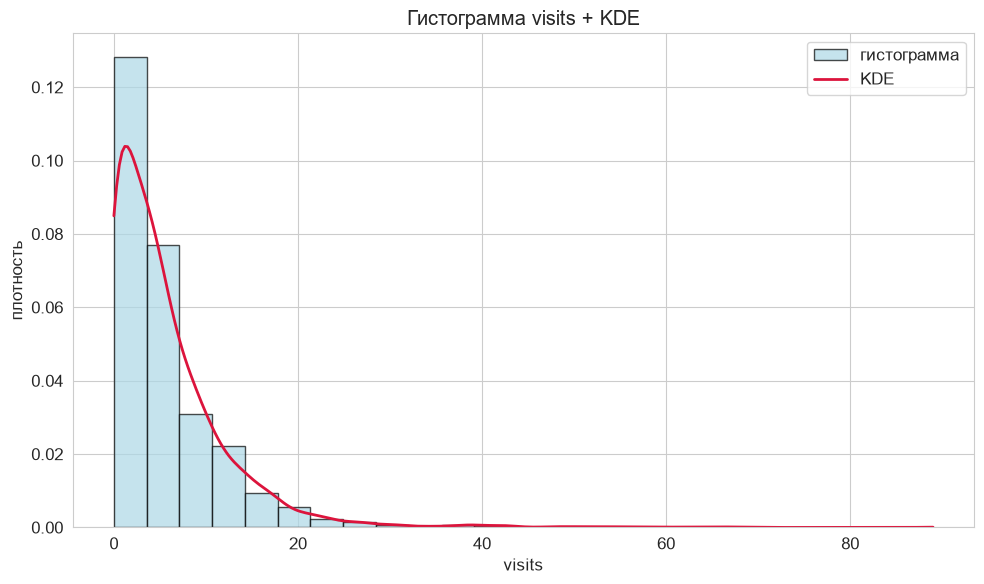

In [10]:
# 3. Гистограмма visits с кривой плотности (KDE)
fig, ax = plt.subplots()
ax.hist(df["visits"], bins=25, density=True, color="lightblue",
        edgecolor="black", alpha=0.7, label="гистограмма")

# KDE по данным
kde = stats.gaussian_kde(df["visits"].dropna())
xs = np.linspace(df["visits"].min(), df["visits"].max(), 300)
ax.plot(xs, kde(xs), color="crimson", lw=2, label="KDE")

ax.set_xlabel("visits")
ax.set_ylabel("плотность")
ax.set_title("Гистограмма visits + KDE")
ax.legend()
plt.tight_layout()
plt.show()


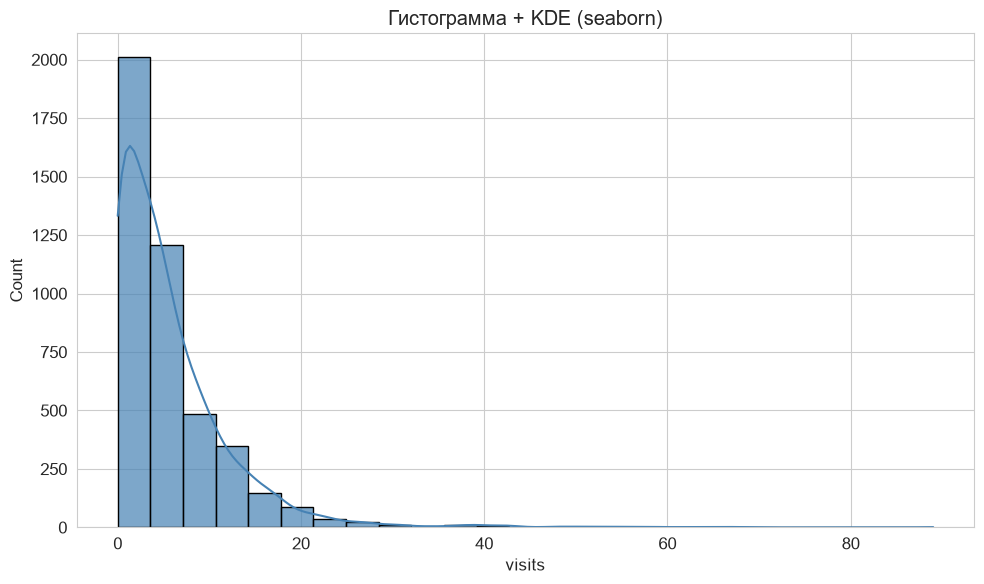

In [9]:
# То же через seaborn
plt.figure()
sns.histplot(df["visits"], bins=25, kde=True, color="steelblue",
             edgecolor="black", alpha=0.7)
plt.xlabel("visits")
plt.title("Гистограмма + KDE (seaborn)")
plt.tight_layout()
plt.show()


---
## 2. Среднее и стандартная ошибка среднего (SE)

$$
\mathrm{SE} = \frac{s}{\sqrt{n}},
$$
где $s$ — выборочное стандартное отклонение, $n$ — объём выборки.


In [15]:
x = df["visits"]
n = x.count()
mean_x = x.mean()
# Явная формула
sd_x = x.std(ddof=1)
se_x = sd_x / np.sqrt(n)

# Спасибо pandas
se_v = x.sem()

print(f"n              = {n}")
print(f"mean           = {mean_x:.4f}")
print(f"sd             = {sd_x:.4f}")
print(f"SE             = {se_x:.4f}")
print(f"SE (pandas)    = {se_v:.4f}")


n              = 4406
mean           = 5.7744
sd             = 6.7592
SE             = 0.1018
SE (pandas)    = 0.1018


---
## 3. Медиана, квантили, summary

`describe` / `quantile` дают «сжатый» портрет распределения.


In [16]:
print("Медиана:", x.median())
print("Квантили 0%, 25%, 50%, 75%, 100%:")
print(x.quantile([0, 0.25, 0.5, 0.75, 1.0]))
print()
print(x.describe())


Медиана: 4.0
Квантили 0%, 25%, 50%, 75%, 100%:
0.00     0.0
0.25     1.0
0.50     4.0
0.75     8.0
1.00    89.0
Name: visits, dtype: float64

count    4406.000000
mean        5.774399
std         6.759225
min         0.000000
25%         1.000000
50%         4.000000
75%         8.000000
max        89.000000
Name: visits, dtype: float64


---
## 4. Асимметрия (skewness) и эксцесс (kurtosis)

- **Skewness** > 0 — правый хвост длиннее (типично для сумм платежей).
- **Kurtosis** (excess) > 0 — хвосты тяжелее, чем у нормального.

В SciPy: `stats.skew`, `stats.kurtosis` (по умолчанию *excess* kurtosis).


In [17]:
sk = stats.skew(x, bias=False)
ku = stats.kurtosis(x, bias=False)
print(f"skewness = {sk:.4f}")
print(f"kurtosis (excess) = {ku:.4f}")


skewness = 3.3393
kurtosis (excess) = 20.2308


---
## 5. Описательные статистики **по группам**

`groupby` + агрегирующая функция — аналог сводных таблиц по фактору.


In [19]:
# 7. Медиана и квартили visits по полу
print("Visits по gender:")
print(df.groupby('gender')['visits'].quantile([0, 0.25, 0.5, 0.75, 1.0]).round(2))

# Или более наглядно через describe():
print("\nСводка visits по gender:")
print(df.groupby('gender')['visits'].describe().round(2))


Visits по gender:
gender      
female  0.00     0.0
        0.25     2.0
        0.50     4.0
        0.75     8.0
        1.00    61.0
male    0.00     0.0
        0.25     1.0
        0.50     4.0
        0.75     7.0
        1.00    89.0
Name: visits, dtype: float64

Сводка visits по gender:
         count  mean   std  min  25%  50%  75%   max
gender                                              
female  2628.0  6.01  6.59  0.0  2.0  4.0  8.0  61.0
male    1778.0  5.42  6.99  0.0  1.0  4.0  7.0  89.0


---
## 6. Boxplot по категориям

«Ящик с усами» показывает медиану, квартили и выбросы по группам.


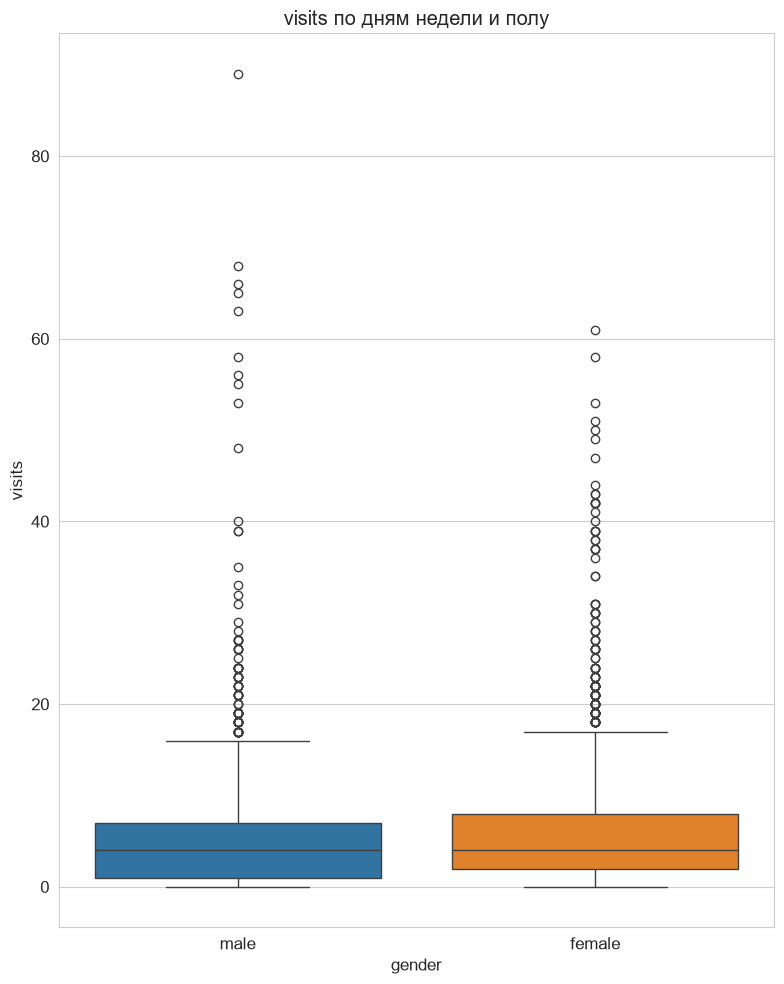

In [23]:
plt.figure(figsize=(8, 10))
sns.boxplot(data=df, x="gender", y="visits", hue="gender")
plt.title("visits по дням недели и полу")
plt.tight_layout()
plt.show()


---
## 7. Медианы в разрезе двух факторов

Сводная таблица медиан, затем столбчатая диаграмма.


region  midwest  northeast  other  west
gender                                 
female      4.0        4.0    4.0   5.0
male        3.0        4.0    3.0   4.0


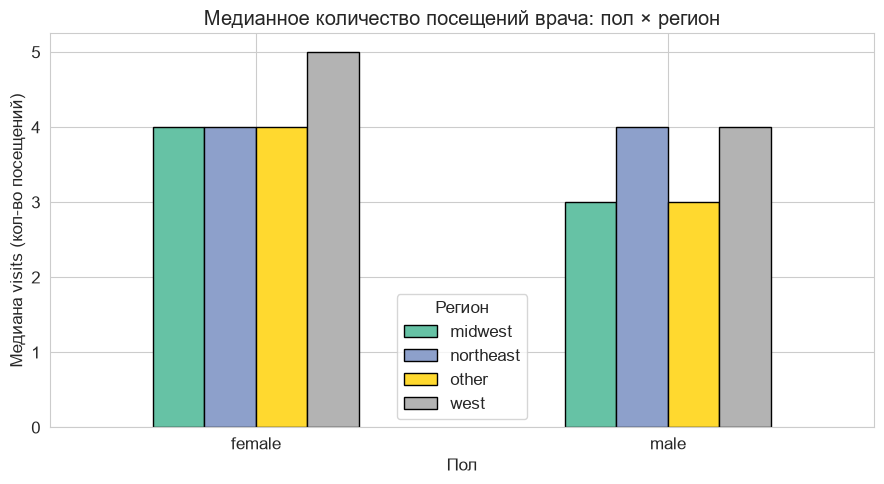

In [25]:
med_two = df.groupby(['gender', 'region'])['visits'].median().unstack()
print(med_two.round(2))

med_two.plot(kind="bar", figsize=(9, 5), edgecolor="black", colormap="Set2")

plt.ylabel("Медиана visits (кол-во посещений)")
plt.xlabel("Пол")
plt.title("Медианное количество посещений врача: пол × регион")
plt.xticks(rotation=0)
plt.legend(title="Регион")
plt.tight_layout()
plt.show()


---
## 8. Barplot для одной группировки

Сначала считаем агрегат, потом рисуем столбцы.


Медиана возраста по married (вся выборка):
married
no     7.5
yes    7.2
Name: age, dtype: float64

Медиана возраста по married и gender:
gender   female  male
married              
no          7.5   7.4
yes         7.1   7.2


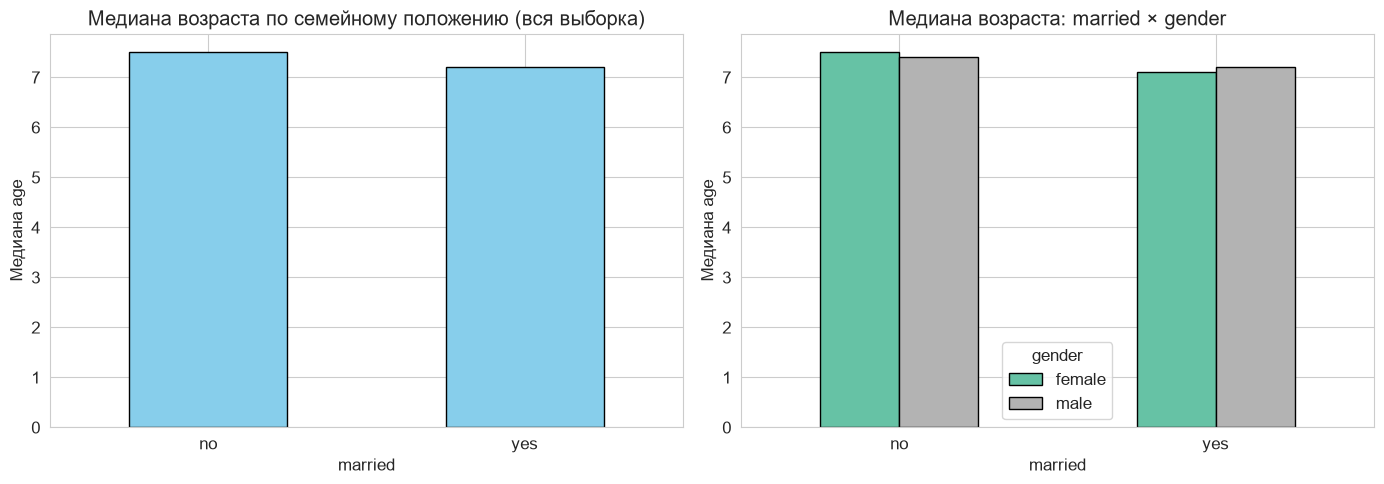

In [27]:
# По всей выборке
median_age_married = df.groupby('married')['age'].median()
print("Медиана возраста по married (вся выборка):")
print(median_age_married.round(2))

# Отдельно для мужчин и женщин
median_age_married_gender = df.groupby(['married', 'gender'])['age'].median().unstack()
print("\nМедиана возраста по married и gender:")
print(median_age_married_gender.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: по всей выборке
median_age_married.plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Медиана возраста по семейному положению (вся выборка)')
axes[0].set_ylabel('Медиана age')
axes[0].set_xlabel('married')
axes[0].tick_params(axis='x', rotation=0)

# График 2: по полу
median_age_married_gender.plot(kind='bar', ax=axes[1], edgecolor='black', colormap='Set2')
axes[1].set_title('Медиана возраста: married × gender')
axes[1].set_ylabel('Медиана age')
axes[1].set_xlabel('married')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='gender')

plt.tight_layout()
plt.show()


---
## Шпаргалка по методам (Python)

| Задача | Код |
|--------|-----|
| Загрузка CSV | `pd.read_csv(path_or_url)` |
| Среднее / sd | `s.mean()`, `s.std(ddof=1)` |
| SE среднего | `s.std(ddof=1) / np.sqrt(s.count())` |
| Медиана, квантили | `s.median()`, `s.quantile([0.25, 0.5, 0.75])` |
| Summary | `s.describe()` / `df.describe()` |
| Skewness / kurtosis | `stats.skew(x)`, `stats.kurtosis(x)` |
| По группам | `df.groupby("A")["y"].mean()` / `.median()` / `.describe()` |
| Два фактора | `df.groupby(["A", "B"])["y"].median().unstack()` |
| Гистограмма + KDE | `plt.hist(..., density=True)` + KDE / `sns.histplot(..., kde=True)` |
| Boxplot | `sns.boxplot(data=df, x="A", y="y")` |
| Barplot | `series.plot(kind="bar")` |

